In [1]:
import pandas as pd
import numpy as np

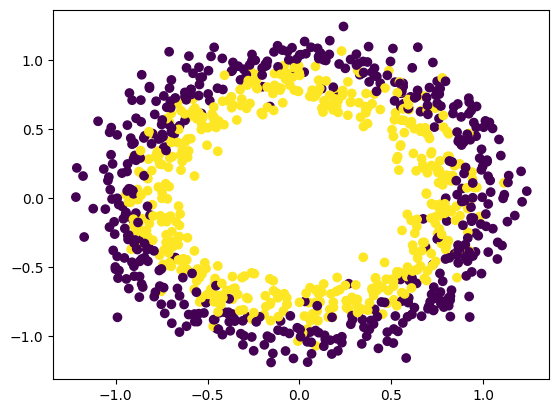

In [3]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
x, y = make_circles(n_samples=1000, noise=0.1, random_state=1)

plt.scatter(x[:, 0], x[:, 1], c=y)
plt.show()




In [4]:
import tensorflow

In [6]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [7]:
model = Sequential([
    Dense(10, activation='relu', input_shape=(2,)),
    Dense(5, activation='relu'),
    Dense(1, activation='linear')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91 (364.00 B)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(loss='binary_crossentropy', metrics=['accuracy'],optimizer='adam')

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
history1 = model.fit(x_train,y_train,validation_data=[x_test,y_test],epochs=200)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4325 - loss: 3.4864 - val_accuracy: 0.4250 - val_loss: 3.0803
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4475 - loss: 2.1127 - val_accuracy: 0.4800 - val_loss: 1.1199
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4512 - loss: 0.8973 - val_accuracy: 0.4500 - val_loss: 0.8244
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4437 - loss: 0.8350 - val_accuracy: 0.4550 - val_loss: 0.8091
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4225 - loss: 0.8188 - val_accuracy: 0.4450 - val_loss: 0.7997
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4338 - loss: 0.8069 - val_accuracy: 0.4450 - val_loss: 0.7906
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4363 - loss: 0.7963 - val_accuracy: 0.4250 - val_loss: 0.7830
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4375 - loss: 0.7854 - val_accuracy: 0.4300 - v

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 768us/step


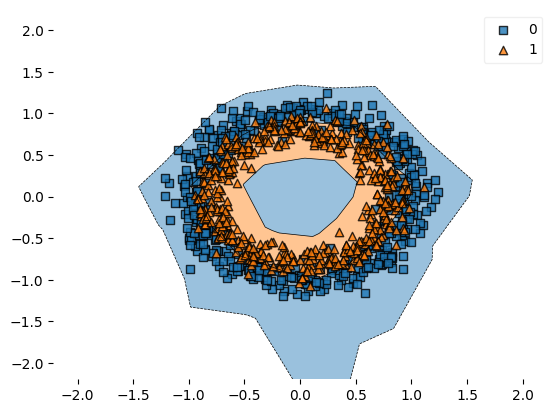

In [21]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x,y,model)
plt.show()





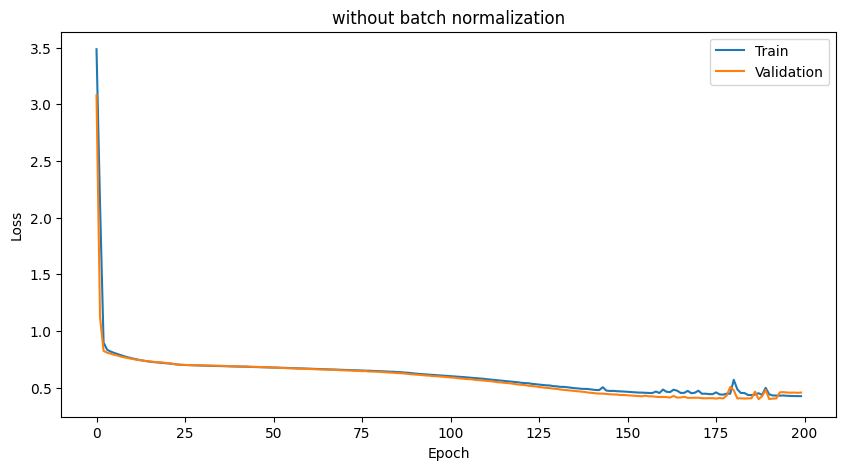

In [33]:

plt.figure(figsize=(10,5))
plt.title('without batch normalization')
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

In [24]:
from tensorflow.keras.layers import BatchNormalization
model2 = Sequential([
    Dense(10, activation='relu', input_shape=(2,)),
    BatchNormalization(),
    Dense(5, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='linear')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5)              │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 30 (120.00 B)

In [26]:
model2.compile(loss='binary_crossentropy', metrics=['accuracy'],optimizer='adam')

In [27]:
history2 = model2.fit(x_train,y_train,validation_data=[x_test,y_test],epochs=200)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4625 - loss: 5.6125 - val_accuracy: 0.4850 - val_loss: 4.3462
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4550 - loss: 4.9606 - val_accuracy: 0.4850 - val_loss: 5.1081
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4512 - loss: 4.3787 - val_accuracy: 0.4850 - val_loss: 5.9895
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4600 - loss: 4.2783 - val_accuracy: 0.4850 - val_loss: 6.8874
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4688 - loss: 4.1165 - val_accuracy: 0.4850 - val_loss: 7.1019
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4725 - loss: 3.9814 - val_accuracy: 0.4850 - val_loss: 6.8352
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4750 - loss: 3.8134 - val_accuracy: 0.4850 - val_loss: 5.4916
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4812 - loss: 3.7300 - val_accuracy: 0.4850 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 787us/step


<Axes: >

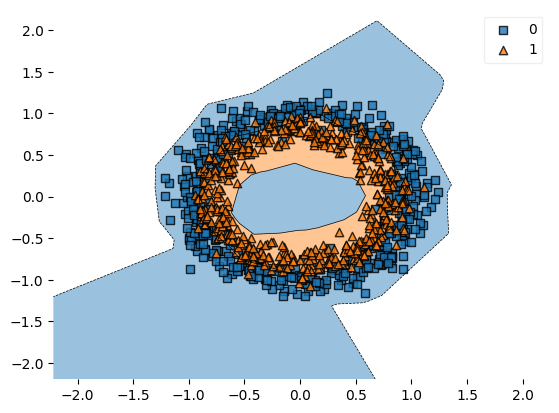

In [28]:
plot_decision_regions(x,y,model2)

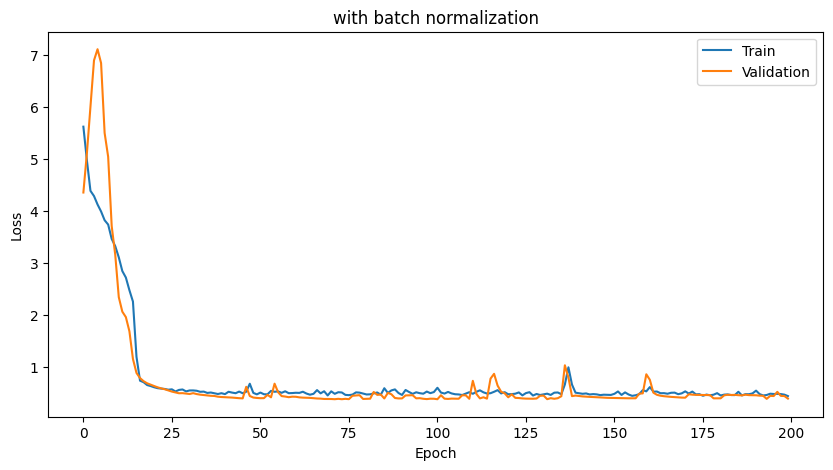

In [34]:
plt.figure(figsize=(10,5))
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('with batch normalization')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])